1\. Write a function that converts number representation, bin<->dec<->hex. (Clearly using the corresponding python built-in functions is not fair..)

In [46]:
#int -> bin
def bin(n):
    sinv = ''
    while(n > 0):
        sinv += str(n % 2)
        n = int(n/2)
    return sinv[::-1]

#bin -> int
def int2(b):
    n = 0
    for i in range(len(b)):
        n += int(b[i])*2**(len(b)-1-i)
    return n

#int -> hexa
def hexa(n):
    sinv = ''
    while(n > 0):
        if(n % 16 < 10):
            sinv += str(n % 16)
        elif(n % 16 == 10):
            sinv += 'A'
        elif(n % 16 == 11):
            sinv += 'B' 
        elif(n % 16 == 12):
            sinv += 'C' 
        elif(n % 16 == 13):
            sinv += 'D' 
        elif(n % 16 == 14):
            sinv += 'E' 
        else:
            sinv += 'F' 
        n = int(n/16)
    return sinv[::-1]
#hexa -> int
def int16(h):
    n = 0
    for i in range(len(h)):
        if(h[i] == 'A'):
            n += 10*16**(len(h)-1-i)
        elif(h[i] == 'B'):
            n += 11*16**(len(h)-1-i)
        elif(h[i] == 'C'):
            n += 12*16**(len(h)-1-i)
        elif(h[i] == 'D'):
            n += 13*16**(len(h)-1-i)
        elif(h[i] == 'E'):
            n += 14*16**(len(h)-1-i)
        elif(h[i] == 'F'):
            n += 15*16**(len(h)-1-i)
        else:
            n += int(h[i])*16**(len(h)-1-i)
    return n

n = 79
h = hexa(n)
print(h)
print(int16(h))

4F
79


2\. Write a function that converts a 32 bit word into a single precision floating point (i.e. interprets the various bits as sign, mantissa and exponent)

In [61]:
def converter(w):
    m = 1
    for i in range(23):
        m += int(w[9+i])*2**(-i-1)
    print("mantissa: ", m)
    e = -127
    for j in range(8):
        e += int(w[1+j])*2**(8-j-1)   
    print("esponente: ", e)
    return (-1)**(int(w[31]))*m*2**(e)

w = '01000100101000000000001100000000'
print("numero in base 10: ", converter(w))
        

mantissa:  1.250091552734375
esponente:  10
numero in base 10:  1280.09375


3\. Write a program to determine the underflow and overflow limits (within a factor of 2) for python on your computer. 

**Tips**: define two variables inizialized to 1 and halve/double them enough time to exceed the under/over-flow limits  

3.6260443998244473e-217
2.7578261315509936e+216


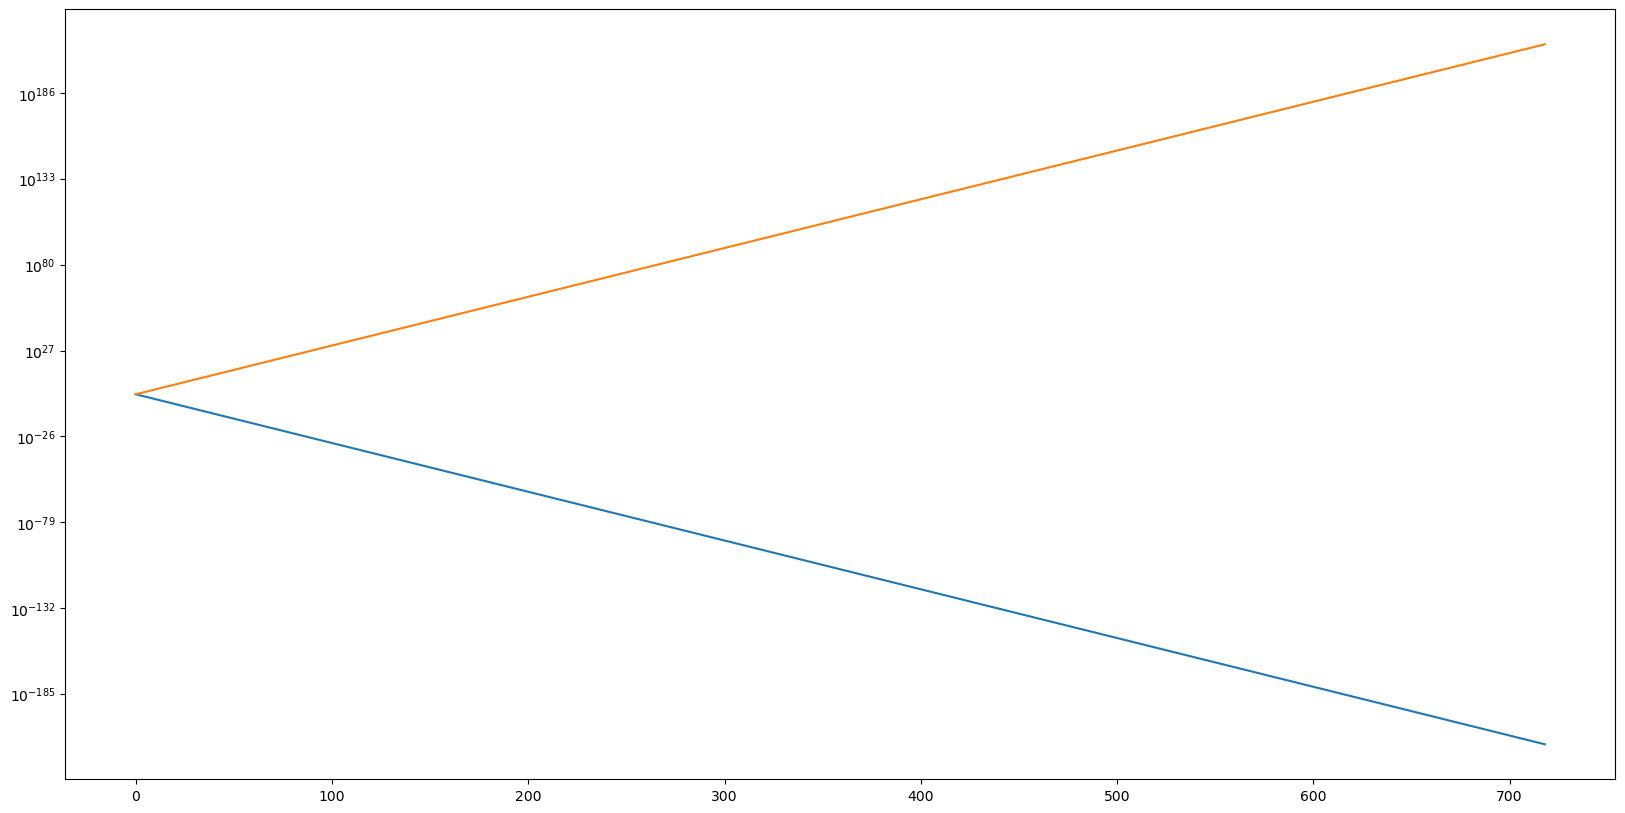

In [85]:
import matplotlib.pyplot as plt
a = []
b = []
index = []
auxa = 1
auxb = 1
for i in range(719):
    a.append(auxa)
    b.append(auxb)
    index.append(i)
    auxa = auxa/2
    auxb = float(auxb*2)
fig, ax = plt.subplots(figsize = (20,10))
print(auxa)
print(auxb)
ax.plot(index,a)
ax.plot(index,b)
ax.set_yscale('log')
plt.show()


4\. Write a program to determine the machine precision

**Tips**: define a new variable by adding a smaller and smaller value (proceeding similarly to prob. 2) to an original variable and check the point where the two are the same 

In [90]:
a = 1
index = 1
while(not(a == a+2**(-index))):
    index += 1
print(2**(-index))

1.1102230246251565e-16


5\. Write a function that takes in input three parameters $a$, $b$ and $c$ and prints out the two solutions to the quadratic equation $ax^2+bx+c=0$ using the standard formula:
$$
x=\frac{-b\pm\sqrt{b^2-4ac}}{2a}
$$

(a) use the program to compute the solution for $a=0.001$, $b=1000$ and $c=0.001$

(b) re-express the standard solution formula by multiplying top and bottom by $-b\mp\sqrt{b^2-4ac}$ and again find the solution for $a=0.001$, $b=1000$ and $c=0.001$. How does it compare with what previously obtained? Why?

(c) write a function that compute the roots of a quadratic equation accurately in all cases

In [99]:
import numpy as np
def solver(a,b,c):
    return (-b - np.sqrt(b**2-4*a*c))/(2*a), (-b + np.sqrt(b**2-4*a*c))/(2*a)
def solver1(a,b,c):
    return (2*c)/(-b + np.sqrt(b**2-4*a*c)), (2*c)/(-b - np.sqrt(b**2-4*a*c))
def correct_solver(a,b,c):
    return (-b - np.sqrt(b**2-4*a*c))/(2*a), (2*c)/(-b - np.sqrt(b**2-4*a*c))
x1, x2 = solver(0.001, 1000, 0.001)
print(x1, " V ", x2)
x3, x4 = solver1(0.001, 1000, 0.001)
print(x3, " V ", x4)
x5, x6 = correct_solver(0.001, 1000, 0.001)
print(x5, " V ", x6)

-999999.999999  V  -9.999894245993346e-07
-1000010.5755125057  V  -1.000000000001e-06
-999999.999999  V  -1.000000000001e-06


6\. Write a program that implements the function $f(x)=x(x−1)$

(a) Calculate the derivative of the function at the point $x = 1$ using the derivative definition:

$$
\frac{{\rm d}f}{{\rm d}x} = \lim_{\delta\to0} \frac{f(x+\delta)-f(x)}{\delta}
$$

with $\delta = 10^{−2}$. Calculate the true value of the same derivative analytically and compare with the answer your program gives. The two will not agree perfectly. Why not?

(b) Repeat the calculation for $\delta = 10^{−4}, 10^{−6}, 10^{−8}, 10^{−10}, 10^{−12}$ and $10^{−14}$. How does the accuracy scales with $\delta$?

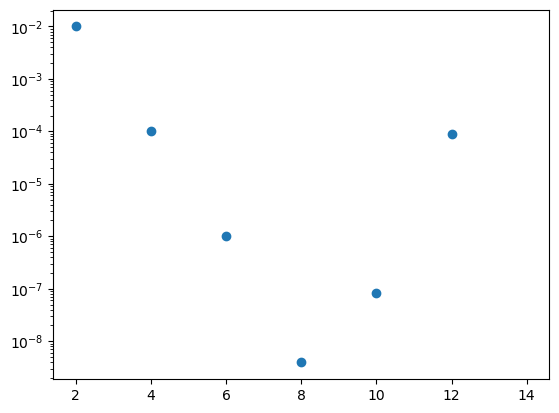

In [125]:
import matplotlib.pyplot as plt
def f(x):
    return x*(x-1)
def derivative_f(x,d):
    return (f(x+d)-f(x))/d
x = 1
Df = []
delta = []
for i in range(2,15,2):
    Df.append(derivative_f(x,10**(-i)))
    delta.append(10**(-i))
plt.plot(range(2,15,2), Df-np.ones(len(Df)), 'o')
plt.semilogy()
plt.show()

7\. Consider the integral of the semicircle of radius 1:
$$
I=\int_{-1}^{1} \sqrt(1-x^2) {\rm d}x
$$
which it's known to be $I=\frac{\pi}{2}=1.57079632679...$.
Alternatively we can use the Riemann definition of the integral:
$$
I=\lim_{N\to\infty} \sum_{k=1}^{N} h y_k 
$$

with $h=2/N$ the width of each of the $N$ slices the domain is divided into and where
$y_k$ is the value of the function at the $k-$th slice.

(a) Write a programe to compute the integral with $N=100$. How does the result compares to the true value?

(b) How much can $N$ be increased if the computation needs to be run in less than a second? What is the gain in running it for 1 minute? 


In [144]:
def f(x):
    return np.sqrt(1-x**2)
N = 10000000
h = 2/N
x = np.linspace(-1,1,N+1)
%time I = sum([h*f(elem) for elem in x])
print("pi/2: ", np.pi/2)
print("Integral: ", I)

CPU times: total: 12.6 s
Wall time: 12.7 s
pi/2:  1.5707963267948966
Integral:  1.5707963267423612
